In [1]:
import jax
import jax.numpy as jnp
import optax
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from scipy.spatial.distance import cdist
import haiku as hk
import numpy as np
import time
from ott.geometry.pointcloud import PointCloud
from ott.problems.linear import linear_problem
from ott.solvers.linear import sinkhorn
from ott.tools.sinkhorn_divergence import sinkhorn_divergence

In [2]:
# 1. Chamfer Distance Function
def chamfer_distance(point_cloud1, point_cloud2):
    pairwise_distances = cdist(point_cloud1, point_cloud2, metric='euclidean')
    total_distance = 0.0
    for i in range(len(point_cloud1)):
        total_distance += np.min(pairwise_distances[i])
    return total_distance / len(point_cloud1)

In [3]:
# 2. Generate Gaussian Blobs
X_np, _ = make_blobs(n_samples=1000, centers=[[0, 0]], cluster_std=1.0, random_state=42)
Y_np, _ = make_blobs(n_samples=1000, centers=[[0, 10], [0, -10]], cluster_std=1.0, random_state=43)
X_all = jnp.array(X_np)
Y_all = jnp.array(Y_np)

n_samples = 500
X_train, X_valid = X_all[:n_samples], X_all[n_samples:2*n_samples]
Y_train, Y_valid = Y_all[:n_samples], Y_all[n_samples:2*n_samples]


In [4]:
# 3. Setup Flow Matching Network
def flow_network_fn(x):
    mlp = hk.Sequential([
        hk.Linear(128), jax.nn.relu,
        hk.Linear(128), jax.nn.relu,
        hk.Linear(2)
    ])
    return mlp(x)

flow_network = hk.transform(flow_network_fn)
key = jax.random.PRNGKey(0)
sample_input = jnp.ones((1, 2))
params_flow = flow_network.init(key, sample_input)
optimizer_flow = optax.adam(1e-3)
opt_state_flow = optimizer_flow.init(params_flow)

# 4. Flow Matching Loss (no noise)
def loss_fn_flow(params, x0, x1, t):
    mean = (1.0 - t) * x0 + t * x1
    x_t = mean  # No noise added
    true_velocity = x1 - x0
    pred_velocity = flow_network.apply(params, None, x_t)
    loss = jnp.mean(jnp.square(pred_velocity - true_velocity))
    return loss

@jax.jit
def train_step_flow(params, opt_state, x0_batch, x1_batch, t_batch):
    loss, grads = jax.value_and_grad(loss_fn_flow)(params, x0_batch, x1_batch, t_batch)
    updates, opt_state = optimizer_flow.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss


Epoch 0, Loss: 64.04706
Epoch 500, Loss: 9.53687
Epoch 1000, Loss: 6.40428
Epoch 1500, Loss: 9.92305

Training time (Flow Matching): 14.11 seconds
Chamfer distance (Flow Matching): 0.239
Approximate Wasserstein distance: 0.87


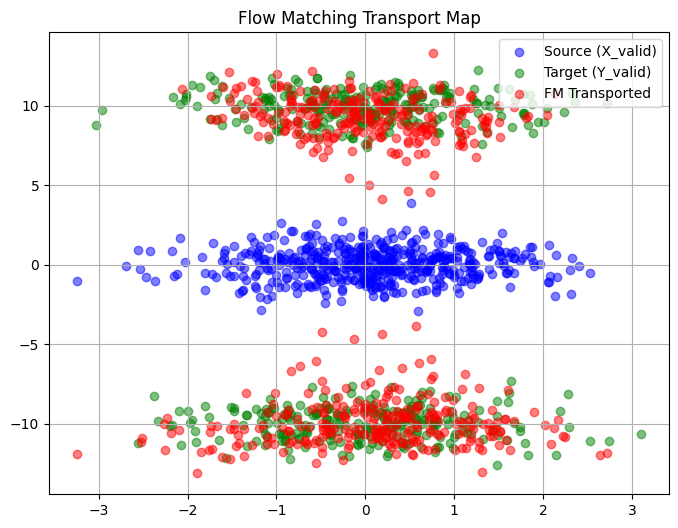

In [5]:
# 5. Train Flow Matching
n_epochs = 2000
batch_size = 128
losses_flow = []

start_time = time.time()
for epoch in range(n_epochs):
    key, subkey_idx = jax.random.split(key)
    idx = jax.random.choice(subkey_idx, X_train.shape[0], (batch_size,), replace=False)
    x0_batch = X_train[idx]
    x1_batch = Y_train[idx]
    
    key, subkey_t = jax.random.split(key)
    t_batch = jax.random.uniform(subkey_t, (batch_size, 1))

    params_flow, opt_state_flow, loss = train_step_flow(params_flow, opt_state_flow, x0_batch, x1_batch, t_batch)
    losses_flow.append(loss)

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.5f}")

end_time = time.time()
print(f"\nTraining time (Flow Matching): {end_time - start_time:.2f} seconds")

# 6. Transport via Flow Matching
def transport_flow(params, source_points, steps=20):
    dt = 1.0 / steps
    x = source_points
    for _ in range(steps):
        v = flow_network.apply(params, None, x)
        x = x + v * dt
    return x

transported_flow = transport_flow(params_flow, X_valid)

# 7. Compute Sinkhorn Wasserstein Distance
wass_dist = sinkhorn_divergence(PointCloud, transported_flow, Y_valid, epsilon=0.1,
                                      a=jnp.ones(len(transported_flow)) / len(transported_flow),
                                      b=jnp.ones(len(Y_valid)) / len(Y_valid))[0]

# 8. Compute Chamfer Distance
transported_flow_np = np.array(transported_flow)
X_valid_np = np.array(X_valid)
Y_valid_np = np.array(Y_valid)

cf_dist_flow = chamfer_distance(transported_flow_np, Y_valid_np)
print("Chamfer distance (Flow Matching):", np.round(cf_dist_flow, 4))
print("Approximate Wasserstein distance:", np.round(float(wass_dist), 2))


# 9. Visualization
plt.figure(figsize=(8,6))

# Transport visualization
plt.scatter(X_valid_np[:,0], X_valid_np[:,1], color='blue', alpha=0.5, label='Source (X_valid)')
plt.scatter(Y_valid_np[:,0], Y_valid_np[:,1], color='green', alpha=0.5, label='Target (Y_valid)')
plt.scatter(transported_flow_np[:,0], transported_flow_np[:,1], color='red', alpha=0.5, label='FM Transported')
plt.title('Flow Matching Transport Map')
plt.legend()
plt.savefig('FM_blobs.png')
plt.grid(True)

plt.show()


## Moon data

Epoch 0, Loss: 6.30093
Epoch 500, Loss: 0.00064
Epoch 1000, Loss: 0.00052
Epoch 1500, Loss: 0.00037

Training time (Flow Matching on Two Moons): 16.52 seconds
Chamfer distance (Two Moons, Flow Matching): 0.0125
Approximate Wasserstein distance: 0.0001881420612335205


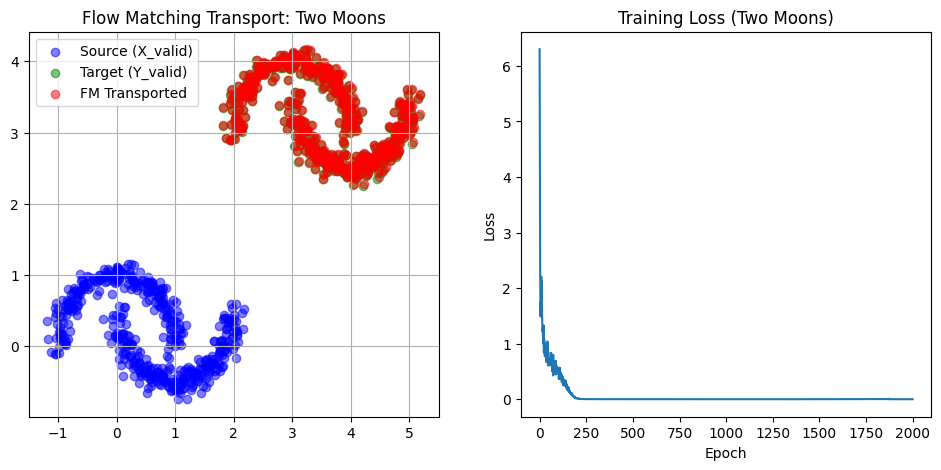

In [7]:
from sklearn.datasets import make_moons

# 1. Create Two Moons data
X_np, labels_X = make_moons(n_samples=1000, noise=0.1, random_state=42)
Y_np, labels_Y = make_moons(n_samples=1000, noise=0.1, random_state=42)

offset = np.array([3, 3])
Y_np = Y_np + offset

# 2. Convert to JAX arrays
X_all = jnp.array(X_np)
Y_all = jnp.array(Y_np)

n_samples = 500 
X_train, X_valid = X_all[:n_samples], X_all[n_samples:2*n_samples]
Y_train, Y_valid = Y_all[:n_samples], Y_all[n_samples:2*n_samples]

# 3. Reinitialize model
key = jax.random.PRNGKey(1)  # new random seed
sample_input = jnp.ones((1, 2))
params_flow = flow_network.init(key, sample_input)
opt_state_flow = optimizer_flow.init(params_flow)

# 4. Train Flow Matching
n_epochs = 2000
batch_size = 128
losses_flow = []

start_time = time.time()
for epoch in range(n_epochs):
    key, subkey_idx = jax.random.split(key)
    idx = jax.random.choice(subkey_idx, X_train.shape[0], (batch_size,), replace=False)
    x0_batch = X_train[idx]
    x1_batch = Y_train[idx]
    
    key, subkey_t = jax.random.split(key)
    t_batch = jax.random.uniform(subkey_t, (batch_size, 1))

    params_flow, opt_state_flow, loss = train_step_flow(params_flow, opt_state_flow, x0_batch, x1_batch, t_batch)
    losses_flow.append(loss)

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.5f}")

end_time = time.time()
print(f"\nTraining time (Flow Matching on Two Moons): {end_time - start_time:.2f} seconds")

# 5. Transport validation set
transported_flow = transport_flow(params_flow, X_valid)

# 6. Evaluate
wass_dist = sinkhorn_divergence(PointCloud, transported_flow, Y_valid, epsilon=0.1,
                                      a=jnp.ones(len(transported_flow)) / len(transported_flow),
                                      b=jnp.ones(len(Y_valid)) / len(Y_valid))[0]

transported_flow_np = np.array(transported_flow)
X_valid_np = np.array(X_valid)
Y_valid_np = np.array(Y_valid)

cf_dist_flow = chamfer_distance(transported_flow_np, Y_valid_np)
print("Chamfer distance (Two Moons, Flow Matching):", np.round(cf_dist_flow, 4))
print("Approximate Wasserstein distance:", float(wass_dist))


# 7. Visualization
plt.figure(figsize=(18,5))

# Transport visualization
plt.subplot(1,3,1)
plt.scatter(X_valid_np[:,0], X_valid_np[:,1], color='blue', alpha=0.5, label='Source (X_valid)')
plt.scatter(Y_valid_np[:,0], Y_valid_np[:,1], color='green', alpha=0.5, label='Target (Y_valid)')
plt.scatter(transported_flow_np[:,0], transported_flow_np[:,1], color='red', alpha=0.5, label='FM Transported')
plt.title('Flow Matching Transport: Two Moons')
plt.legend()
plt.grid(True)

# Training loss plot
plt.subplot(1,3,2)
plt.plot(np.array(losses_flow))
plt.title("Training Loss (Two Moons)")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()


## Swiss roll

In [11]:
from sklearn.datasets import make_swiss_roll
from ott.geometry.pointcloud import PointCloud
from ott.tools.sinkhorn_divergence import sinkhorn_divergence

# 1. Create Swiss Roll data
X_np, _ = make_swiss_roll(n_samples=1000, noise=1.5, random_state=42)
Y_np, _ = make_swiss_roll(n_samples=1000, noise=0.0, random_state=42)

X_all = jnp.array(X_np)
Y_all = jnp.array(Y_np)

n_samples = 500 
X_train, X_valid = X_all[:n_samples], X_all[n_samples:2*n_samples]
Y_train, Y_valid = Y_all[:n_samples], Y_all[n_samples:2*n_samples]



In [12]:
# 3. Setup Flow Matching Network
def flow_network_fn(x):
    mlp = hk.Sequential([
        hk.Linear(128), jax.nn.relu,
        hk.Linear(128), jax.nn.relu,
        hk.Linear(3)
    ])
    return mlp(x)

flow_network = hk.transform(flow_network_fn)
key = jax.random.PRNGKey(0)
sample_input = jnp.ones((1, 3))
params_flow = flow_network.init(key, sample_input)
optimizer_flow = optax.adam(1e-3)
opt_state_flow = optimizer_flow.init(params_flow)



In [13]:
from sklearn.datasets import make_swiss_roll
from ott.geometry.pointcloud import PointCloud
# 1. Create Swiss Roll data
X_np, _ = make_swiss_roll(n_samples=1000, noise=1.5, random_state=42)
Y_np, _ = make_swiss_roll(n_samples=1000, noise=0.0, random_state=42)

X_all = jnp.array(X_np)
Y_all = jnp.array(Y_np)

n_samples = 500 
X_train, X_valid = X_all[:n_samples], X_all[n_samples:2*n_samples]
Y_train, Y_valid = Y_all[:n_samples], Y_all[n_samples:2*n_samples]

# 2. Define dynamic flow network for 3D
def flow_network_fn(output_dim):
    def _fn(x):
        mlp = hk.Sequential([
            hk.Linear(128), jax.nn.relu,
            hk.Linear(128), jax.nn.relu,
            hk.Linear(output_dim)
        ])
        return mlp(x)
    return _fn

Epoch 0, Loss: 15.69218
Epoch 500, Loss: 1.92546
Epoch 1000, Loss: 1.86035
Epoch 1500, Loss: 2.10024

Training time (Flow Matching on Swiss Roll): 15.35 seconds
Approximate Wasserstein distance: 3.94
Chamfer distance (Flow Matching): 1.5382


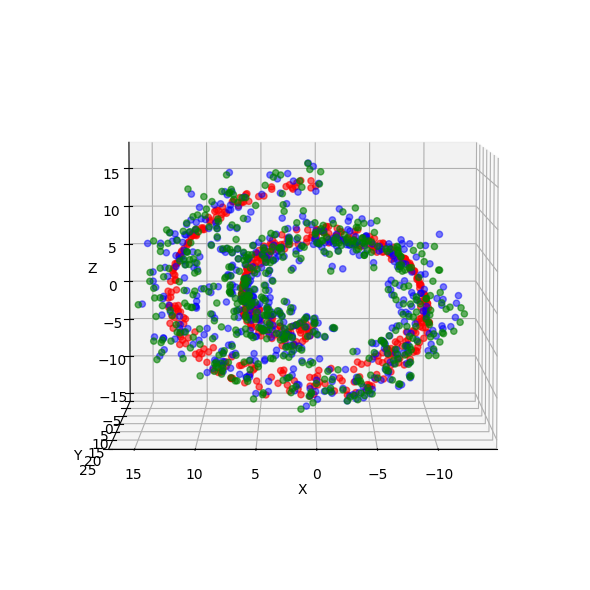

In [15]:
# 3. Reinitialize model for 3D
key = jax.random.PRNGKey(2)
flow_network = hk.transform(flow_network_fn(output_dim=3))
sample_input = jnp.ones((1, 3))
params_flow = flow_network.init(key, sample_input)
optimizer_flow = optax.adam(1e-4)
opt_state_flow = optimizer_flow.init(params_flow)

# 4. Define loss and training step
def loss_fn_flow(params, x0, x1, t):
    mean = (1.0 - t) * x0 + t * x1
    x_t = mean
    true_velocity = x1 - x0
    pred_velocity = flow_network.apply(params, None, x_t)
    loss = jnp.mean(jnp.square(pred_velocity - true_velocity))
    return loss

@jax.jit
def train_step_flow(params, opt_state, x0_batch, x1_batch, t_batch):
    loss, grads = jax.value_and_grad(loss_fn_flow)(params, x0_batch, x1_batch, t_batch)
    updates, opt_state = optimizer_flow.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

# 5. Train the model
n_epochs = 2000
batch_size = 128
losses_flow = []

start_time = time.time()
for epoch in range(n_epochs):
    key, subkey_idx = jax.random.split(key)
    idx = jax.random.choice(subkey_idx, X_train.shape[0], (batch_size,), replace=False)
    x0_batch = X_train[idx]
    x1_batch = Y_train[idx]
    
    key, subkey_t = jax.random.split(key)
    t_batch = jax.random.uniform(subkey_t, (batch_size, 1))

    params_flow, opt_state_flow, loss = train_step_flow(params_flow, opt_state_flow, x0_batch, x1_batch, t_batch)
    losses_flow.append(loss)

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.5f}")

end_time = time.time()
print(f"\nTraining time (Flow Matching on Swiss Roll): {end_time - start_time:.2f} seconds")

# 6. Define learned map transport function
def transport_flow(params, source_points, steps=20):
    dt = 1.0 / steps
    x = source_points
    for _ in range(steps):
        v = flow_network.apply(params, None, x)
        x = x + v * dt
    return x

# 7. Transport
transported_X = transport_flow(params_flow, X_valid)

# Compute Wasserstein distance using sinkhorn_divergence
wass_dist = sinkhorn_divergence(PointCloud, transported_X, Y_valid, epsilon=0.1,
                                      a=jnp.ones(len(transported_X)) / len(transported_X),
                                      b=jnp.ones(len(Y_valid)) / len(Y_valid))[0]


print("Approximate Wasserstein distance:", np.round(float(wass_dist), 2))

# 8. Compute Chamfer Distance
transported_flow_np = np.array(transported_X)
X_valid_np = np.array(X_valid)
Y_valid_np = np.array(Y_valid)

cf_dist_flow = chamfer_distance(transported_flow_np, Y_valid_np)
print("Chamfer distance (Flow Matching):", np.round(cf_dist_flow, 4))



# 8. Plot beautifully
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_valid[:, 0], X_valid[:, 1], X_valid[:, 2], c='green', label='Source', alpha=0.6)
ax.scatter(Y_valid[:, 0], Y_valid[:, 1], Y_valid[:, 2], c='red', label='Target', alpha=0.6)
ax.scatter(np.array(transported_X)[:, 0], np.array(transported_X)[:, 1], np.array(transported_X)[:, 2], c='blue', label='Transported source', alpha=0.5)

#ax.set_title('Swiss Rolls with transported data (FM)')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
#x.legend()

ax.view_init(elev=5, azim=90)
plt.tight_layout()
plt.savefig('flow_matching_swiss.png')
plt.show()

